In [7]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import anndata
from scipy import stats
import warnings
import logging


working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)



# dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

plt.rcParams['pdf.fonttype'] = 42 

Running Scanpy 1.11.5, on 2026-04-20 10:14.


# Post cliustering and naming as vFB1...10

In [2]:
FB_adata = sc.read ('/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_FB_PIG_2ndIT_ANNOTATED.h5ad')

In [12]:
FB_adata

AnnData object with n_obs × n_vars = 16322 × 3571
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'leiden_08', 'cell_states', 'leiden_07'
    var: 'Average_expression', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Endpoint_status_colors', 'Sample_ID_colors', 'cell_states_colors', 'hvg', 'leiden', 'leiden_07_colors', 'leiden_08_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp

In [13]:
raw_FB_adata= anndata.AnnData(X=FB_adata.raw.X,
                obs=FB_adata.obs, 
                var=FB_adata.raw.var)

In [14]:
raw_FB_adata

AnnData object with n_obs × n_vars = 16322 × 53826
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'leiden_08', 'cell_states', 'leiden_07'
    var: 'Average_expression'

In [4]:
global_raw = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/global objects/global_v7/global_v7_without_unassigned/20240220_el_Xenotransplant_noBR_ANNOTATED_pc39_noreg_CELL_STATES_RAWRAW_with_condition_subsets_v7_no_unassigned.h5ad')

In [5]:
new_adata = global_raw.copy()

# Step 2: Preprocess - Normalize and Log Transform
sc.pp.normalize_total(new_adata)
sc.pp.log1p(new_adata)

In [8]:
global_FB_adata = new_adata [new_adata.obs.cell_type == 'Fibroblasts']

In [9]:
global_FB_adata

View of AnnData object with n_obs × n_vars = 16322 × 53826
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    var: 'Average_expression'
    uns: 'Sample_ID_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [9]:
import pandas as pd
import scanpy as sc

# Assuming FB_adata is already loaded

# Get the groups (cell states)
groups = FB_adata.uns['rank_genes_groups']['names'].dtype.names

# For each group (cell state), extract markers and save as CSV
for group in groups:
    names      = FB_adata.uns['rank_genes_groups']['names'][group]
    scores     = FB_adata.uns['rank_genes_groups']['scores'][group]
    logfoldchanges = FB_adata.uns['rank_genes_groups']['logfoldchanges'][group]
    pvals      = FB_adata.uns['rank_genes_groups']['pvals'][group]
    pvals_adj  = FB_adata.uns['rank_genes_groups']['pvals_adj'][group]

    df = pd.DataFrame({
        'gene': names,
        'score': scores,
        'logfoldchange': logfoldchanges,
        'pval': pvals,
        'pval_adj': pvals_adj
    })

    # Save as CSV; e.g. cellstate_markers_v1_vFB1.csv
    outpath = f'markers_{group}.csv'
    df.to_csv(outpath, index=False)
    print(f'Saved: {outpath}')


Saved: markers_vFB1.csv
Saved: markers_vFB2.csv
Saved: markers_vFB3.csv
Saved: markers_vFB4.csv
Saved: markers_vFB5.csv
Saved: markers_vFB6.csv
Saved: markers_vFB7.csv
Saved: markers_vFB8.csv
Saved: markers_vFB9.csv
Saved: markers_vFB10.csv


In [11]:
groups = FB_adata.uns['rank_genes_groups']['names'].dtype.names

for group in groups:
    names      = FB_adata.uns['rank_genes_groups']['names'][group]
    scores     = FB_adata.uns['rank_genes_groups']['scores'][group]
    logfoldchanges = FB_adata.uns['rank_genes_groups']['logfoldchanges'][group]
    pvals      = FB_adata.uns['rank_genes_groups']['pvals'][group]
    pvals_adj  = FB_adata.uns['rank_genes_groups']['pvals_adj'][group]

    df = pd.DataFrame({
        'gene': names,
        'score': scores,
        'logfoldchange': logfoldchanges,
        'pval': pvals,
        'pval_adj': pvals_adj
    })

    # Filter
    df_filtered = df[(df['logfoldchange'] > 0.5) & (df['pval'] < 0.05)]

    # Save
    outpath = f'markers_{group}_filtered.csv'
    df_filtered.to_csv(outpath, index=False)
    print(f'Saved: {outpath} (n={len(df_filtered)})')


Saved: markers_vFB1_filtered.csv (n=78)
Saved: markers_vFB2_filtered.csv (n=2013)
Saved: markers_vFB3_filtered.csv (n=275)
Saved: markers_vFB4_filtered.csv (n=4087)
Saved: markers_vFB5_filtered.csv (n=349)
Saved: markers_vFB6_filtered.csv (n=472)
Saved: markers_vFB7_filtered.csv (n=512)
Saved: markers_vFB8_filtered.csv (n=957)
Saved: markers_vFB9_filtered.csv (n=628)
Saved: markers_vFB10_filtered.csv (n=2996)


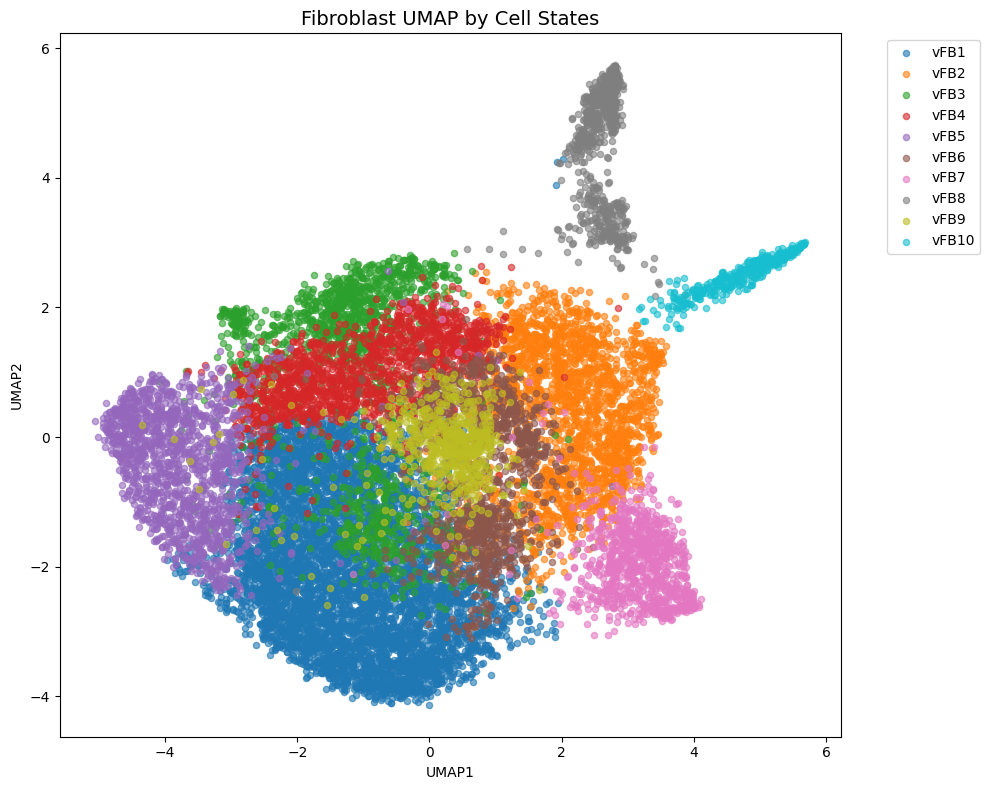

In [15]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure cell_states is properly formatted as categorical
FB_adata.obs['cell_states'] = FB_adata.obs['cell_states'].astype('category')

# 2. Verify colors exist and match categories
if 'cell_states_colors' not in FB_adata.uns:
    print("Creating default colors for cell states")
    n_states = len(FB_adata.obs['cell_states'].cat.categories)
    FB_adata.uns['cell_states_colors'] = plt.cm.tab20(np.linspace(0, 1, n_states))

# 3. Create a dictionary mapping states to colors
state_color_map = dict(zip(
    FB_adata.obs['cell_states'].cat.categories,
    FB_adata.uns['cell_states_colors']
))

# 4. Plot with enforced color mapping
fig, ax = plt.subplots(figsize=(10, 8))
for state, color in state_color_map.items():
    mask = FB_adata.obs['cell_states'] == state
    ax.scatter(
        FB_adata.obsm['X_umap'][mask, 0],
        FB_adata.obsm['X_umap'][mask, 1],
        c=[color],
        label=state,
        s=20,
        alpha=0.6
    )

ax.set_title('Fibroblast UMAP by Cell States', fontsize=14)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

dendrogram data not found (using key=dendrogram_cell_states). Running `sc.tl.dendrogram` with default parameters. For fine tuning it is recommended to run `sc.tl.dendrogram` independently.


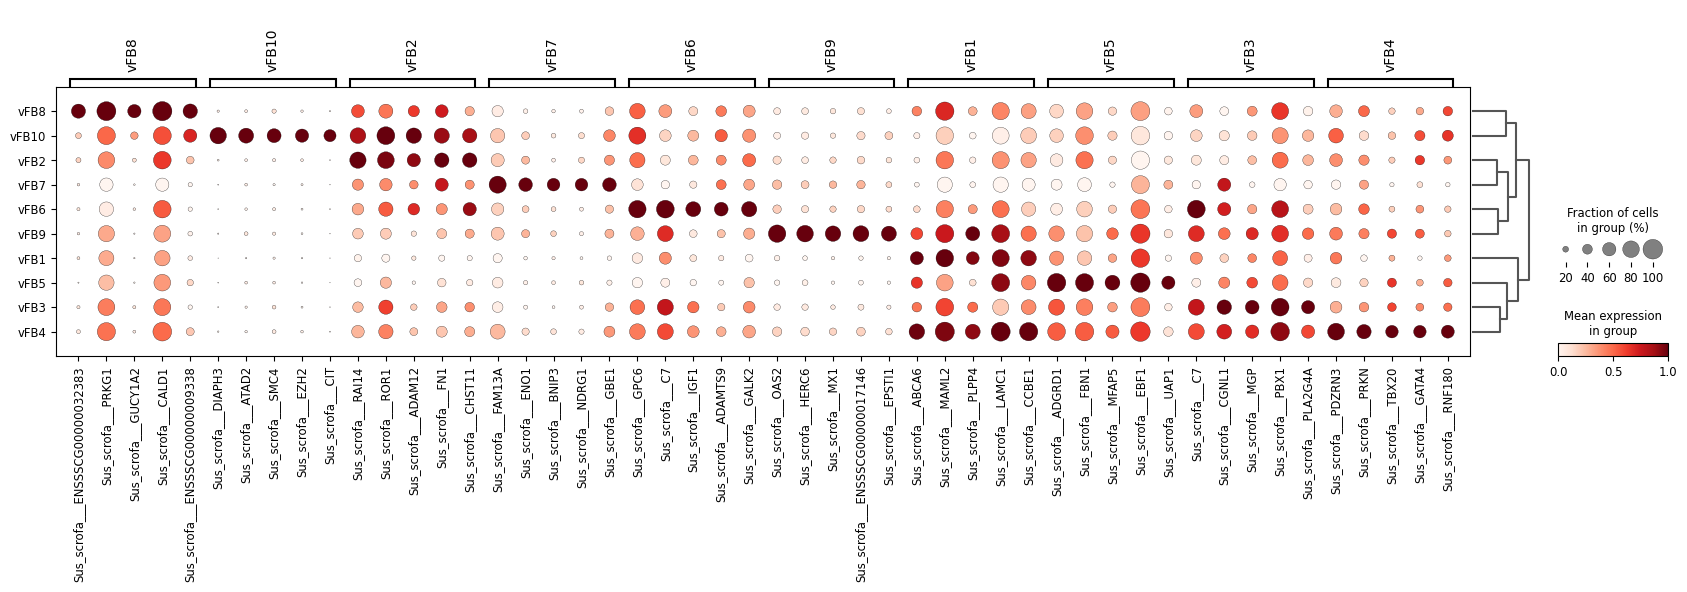

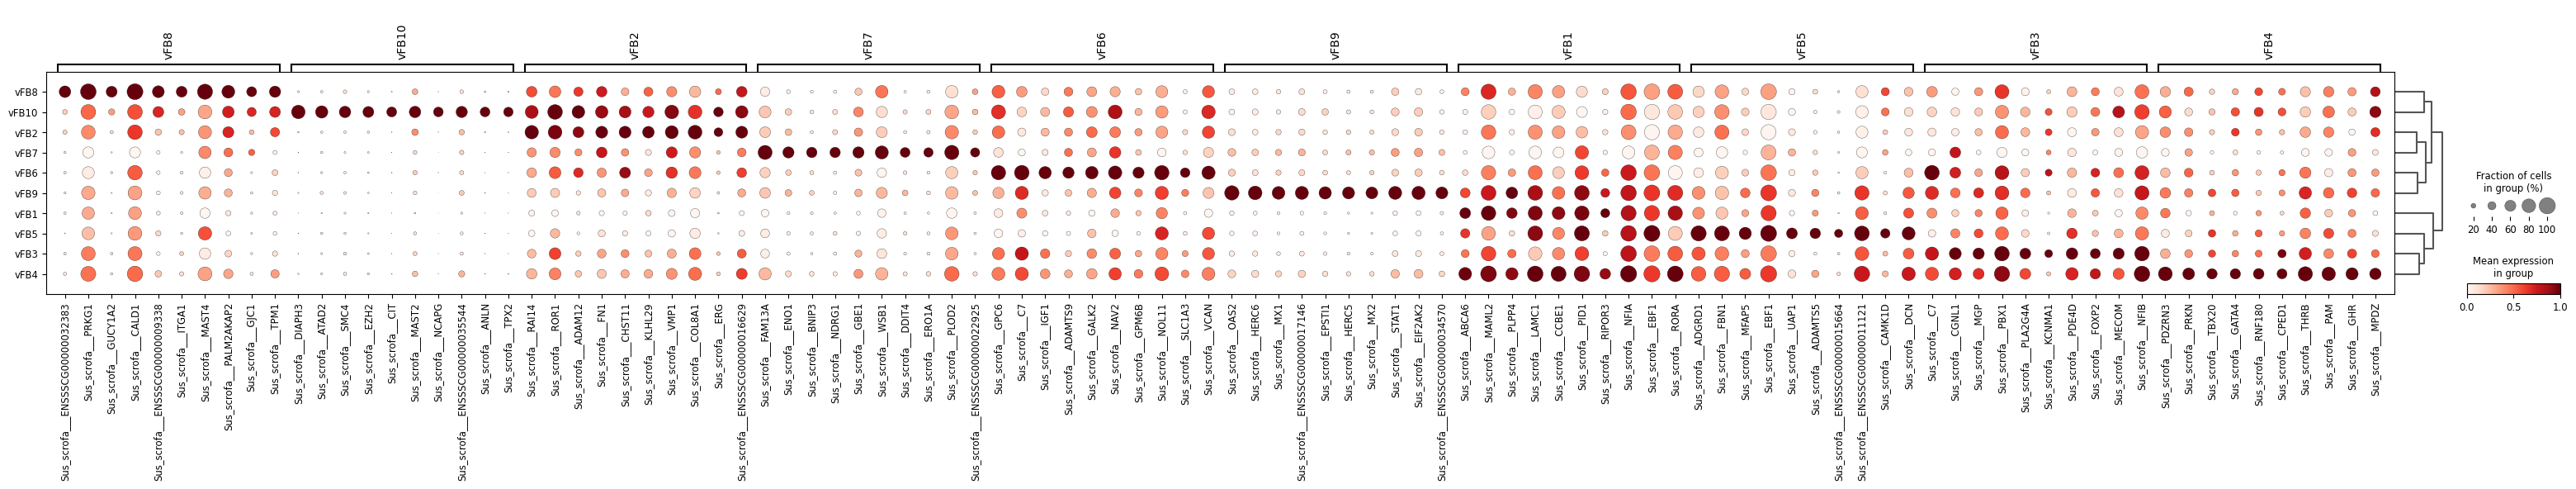

In [16]:
sc.pl.rank_genes_groups_dotplot(FB_adata, key="rank_genes_groups", n_genes=5, standard_scale="var"
                                # , cmap="coolwarm", vmin= -1
                               )
sc.pl.rank_genes_groups_dotplot(FB_adata, key="rank_genes_groups", n_genes=10, standard_scale="var"
                                # , cmap="coolwarm", vmin= -1
                               )

# Checking amrkers

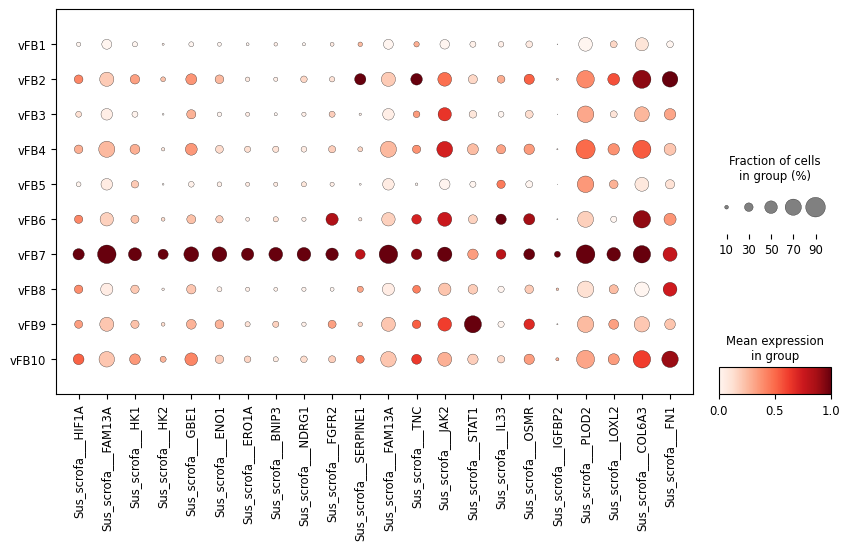

In [33]:
genes_vFB7 = [
       'Sus_scrofa___HIF1A', 'Sus_scrofa___FAM13A',     'Sus_scrofa___HK1',
    'Sus_scrofa___HK2',     'Sus_scrofa___GBE1',
    'Sus_scrofa___ENO1',    'Sus_scrofa___ERO1A',
    'Sus_scrofa___BNIP3',
    'Sus_scrofa___NDRG1',
    'Sus_scrofa___FGFR2',

    'Sus_scrofa___SERPINE1',
     'Sus_scrofa___FAM13A',

    'Sus_scrofa___TNC',

        'Sus_scrofa___JAK2',
            'Sus_scrofa___STAT1',
    'Sus_scrofa___IL33',
    'Sus_scrofa___OSMR',
    'Sus_scrofa___IGFBP2',
        'Sus_scrofa___PLOD2',
        'Sus_scrofa___LOXL2',
        'Sus_scrofa___COL6A3',
        'Sus_scrofa___FN1',
]

sc.pl.dotplot(
    FB_adata,
    var_names=genes_vFB7,
    groupby='cell_states',    # or your cluster column
    color_map='Reds',
    figsize=(10,5),
    standard_scale = 'var'
)


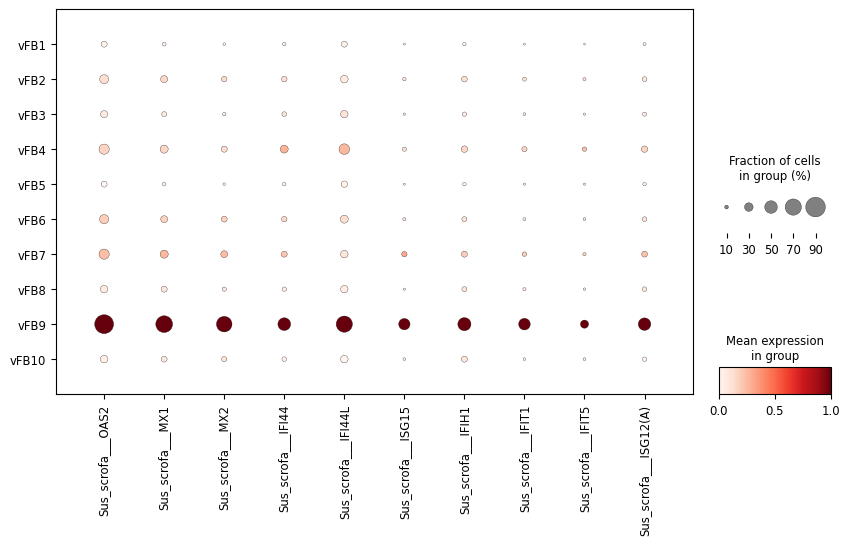

In [49]:
genes_vFB8 = [
       'Sus_scrofa___OAS2', 'Sus_scrofa___MX1',     'Sus_scrofa___MX2','Sus_scrofa___IFI44', 'Sus_scrofa___IFI44L','Sus_scrofa___ISG15',
    'Sus_scrofa___IFIH1',      'Sus_scrofa___IFIT1',     'Sus_scrofa___IFIT5',

   'Sus_scrofa___ISG12(A)',

]

sc.pl.dotplot(
    FB_adata,
    var_names=genes_vFB8,
    groupby='cell_states',    # or your cluster column
    color_map='Reds',
    figsize=(10,5),
    standard_scale = 'var'
)


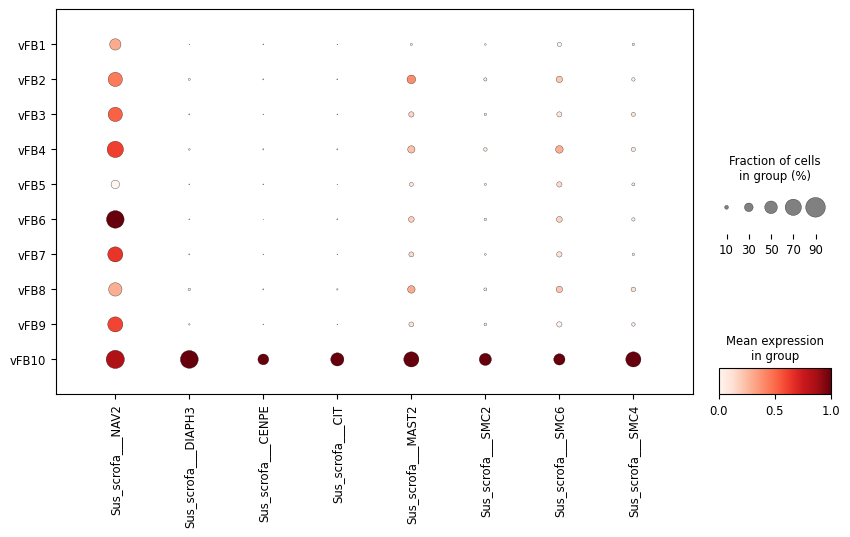

In [55]:
genes_vFB10 = [
       'Sus_scrofa___NAV2', 'Sus_scrofa___DIAPH3', 'Sus_scrofa___CENPE',    'Sus_scrofa___CIT', 'Sus_scrofa___MAST2',
'Sus_scrofa___SMC2','Sus_scrofa___SMC6','Sus_scrofa___SMC4',


]

sc.pl.dotplot(
    FB_adata,
    var_names=genes_vFB10,
    groupby='cell_states',    # or your cluster column
    color_map='Reds',
    figsize=(10,5),
    standard_scale = 'var'
)


# Using clustered FB states (vFB1...10) to map to biological names on the raw object

In [4]:
FB_adata = sc.read ('/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_Fibroblasts_PIG_RAW.h5ad')

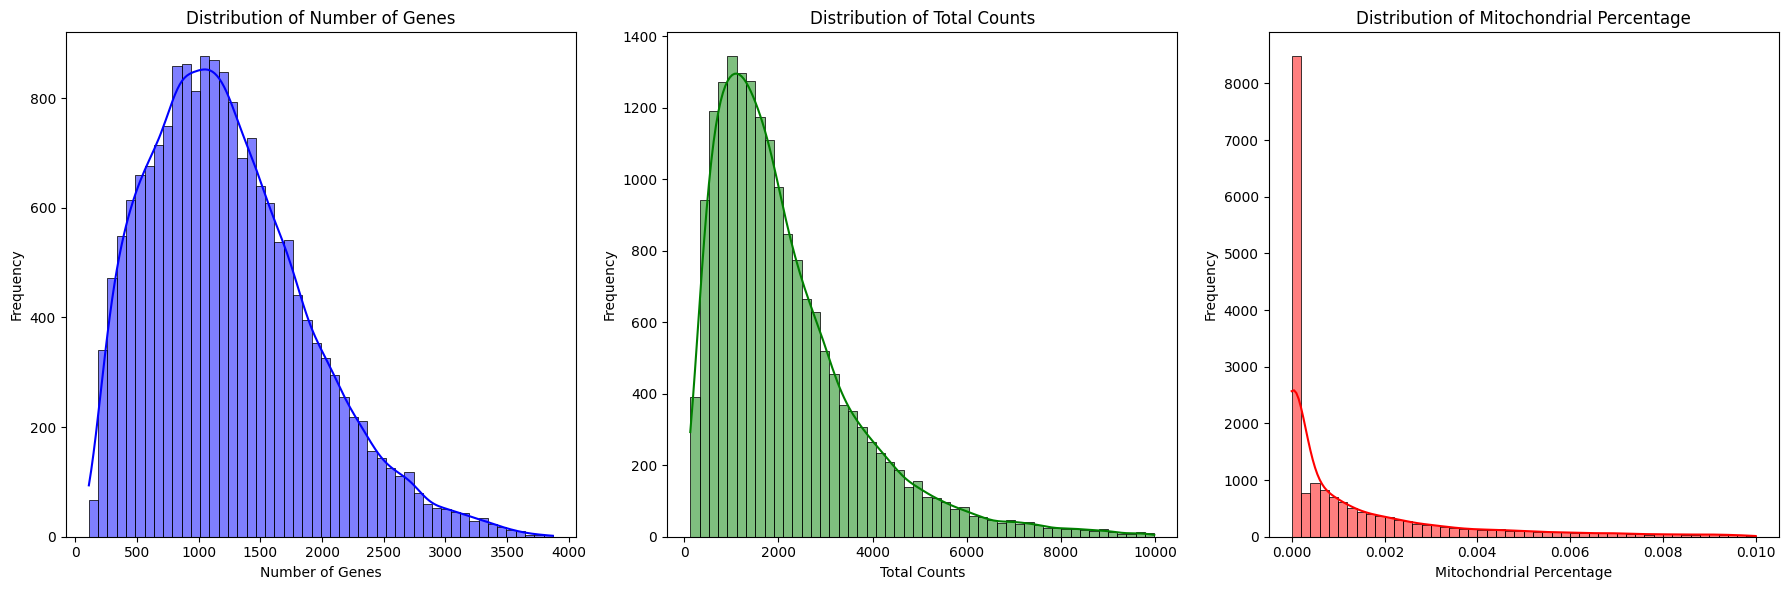

In [8]:
# 1. Visualize the distribution of key variables (n_genes, n_counts, percent_mito)
# Plot the distribution of n_genes, n_counts, and percent_mito

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(FB_adata.obs['n_genes'], kde=True, ax=axes[0], color='blue', bins=50)
axes[0].set_title('Distribution of Number of Genes')
axes[0].set_xlabel('Number of Genes')
axes[0].set_ylabel('Frequency')

sns.histplot(FB_adata.obs['n_counts'], kde=True, ax=axes[1], color='green', bins=50)
axes[1].set_title('Distribution of Total Counts')
axes[1].set_xlabel('Total Counts')
axes[1].set_ylabel('Frequency')

sns.histplot(FB_adata.obs['percent_mito'], kde=True, ax=axes[2], color='red', bins=50)
axes[2].set_title('Distribution of Mitochondrial Percentage')
axes[2].set_xlabel('Mitochondrial Percentage')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

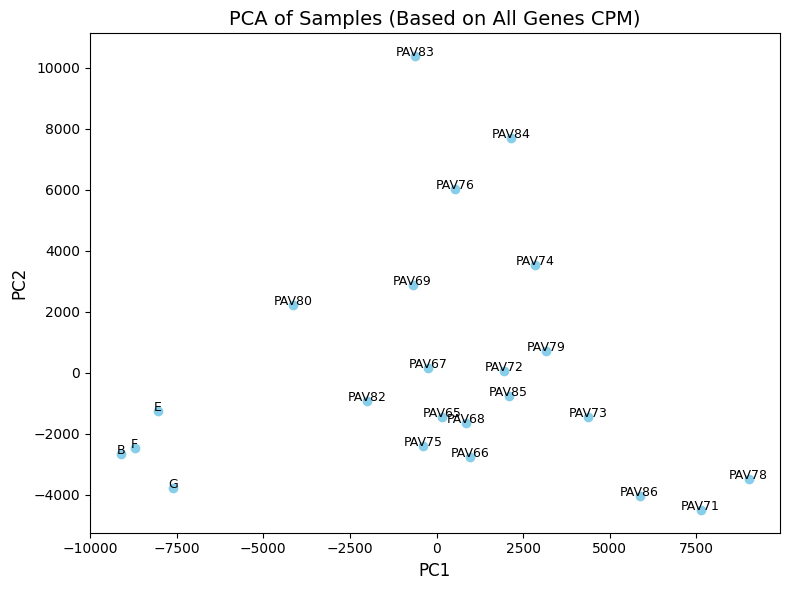

In [9]:
sample_column = 'Sample_ID'

if sample_column not in FB_adata.obs:
    raise ValueError(f"Column '{sample_column}' not found in final_EC_adata.obs")

gene_expression_sums = FB_adata.obs.groupby(sample_column).apply(
    lambda df: FB_adata[df.index, :].X.sum(axis=0)
)

gene_expression_sums = pd.DataFrame(
    data=np.vstack(gene_expression_sums.values),
    index=gene_expression_sums.index,
    columns=FB_adata.var_names
)

total_expression_per_sample = gene_expression_sums.sum(axis=1)
cpm_normalized = gene_expression_sums.div(total_expression_per_sample, axis=0) * 1e6

pca = PCA(n_components=2)
pca_results = pca.fit_transform(cpm_normalized)

pca_df = pd.DataFrame(
    data=pca_results,
    columns=['PC1', 'PC2'],
    index=gene_expression_sums.index
)

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], color='skyblue')
for i, sample in enumerate(pca_df.index):
    plt.text(pca_df.iloc[i, 0], pca_df.iloc[i, 1], sample, fontsize=9, ha='center')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('PCA of Samples (Based on All Genes CPM)', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
sc.pp.normalize_total(FB_adata, target_sum=1e4)
sc.pp.log1p(FB_adata)
FB_adata.raw = FB_adata.copy() 


In [11]:

sc.pp.scale(FB_adata, max_value=10)

# preprocessed_FB_adata = FB_adata.write ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/for_submission/objects/preprocessed_noHVG_FB.h5ad')

In [ ]:
high_genes = sc.pp.highly_variable_genes(FB_adata, min_mean=0.01, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(FB_adata)

# Subset the data to HVGs for dimensionality reduction and clustering
FB_adata_hvg = FB_adata[:, FB_adata.var.highly_variable]

# Save the HVG-only dataset for reproducibility
# FB_adata_hvg = FB_adata.write('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/for_submission/objects/HVG_FB.h5ad')

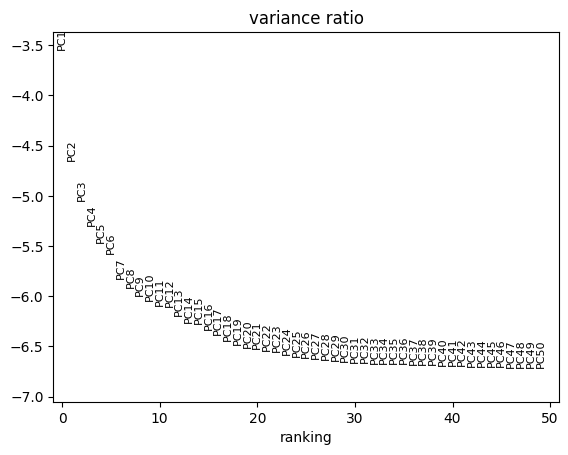

In [13]:
# Perform PCA
sc.tl.pca(FB_adata_hvg, svd_solver='arpack')

# Plot the explained variance to decide how many PCs to use
sc.pl.pca_variance_ratio(FB_adata_hvg, log=True, n_pcs=50)
plt.show()

In [14]:
# Load the main AnnData object and the raw data
FB_adata = sc.read('/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_FB_PIG_2ndIT_ANNOTATED.h5ad')
raw_FB_adata = anndata.AnnData(X=FB_adata.raw.X, obs=FB_adata.obs, var=FB_adata.raw.var)

# 1. Ensure 'cell_states' is properly formatted as categorical
FB_adata.obs['cell_states'] = FB_adata.obs['cell_states'].astype('category')


In [15]:
# Define the renaming map for the clusters you want to change
rename_map = {
    'vFB1': 'Homeostatic_vFB1',
    'vFB2': 'Myo_vFB',
    'vFB7': 'Hypoxia_VFB',
    'vFB9': 'vFB_ISG',
    'vFB10': 'Prolif_vFB'
}

# Apply the renaming to the 'cell_states' column
FB_adata.obs['cell_states'] = FB_adata.obs['cell_states'].cat.rename_categories(rename_map)

# Print the new categories to verify the changes
print("Updated cell state categories:")
print(FB_adata.obs['cell_states'].cat.categories.tolist())


# --- Re-align colors after renaming (if they existed) ---
# Renaming categories does not change the order, so colors should still be aligned.
# This block ensures colors are present for plotting.
if 'cell_states_colors' not in FB_adata.uns:
    print("Creating default colors for cell states")
    n_states = len(FB_adata.obs['cell_states'].cat.categories)
    # The default colormap used by Scanpy is 'tab20'
    FB_adata.uns['cell_states_colors'] = plt.cm.tab20(np.linspace(0, 1, n_states))
else:
    # A sanity check to ensure the number of colors matches the number of categories.
    if len(FB_adata.uns['cell_states_colors']) != len(FB_adata.obs['cell_states'].cat.categories):
        print("Warning: Number of colors does not match number of categories. Creating new default colors.")
        n_states = len(FB_adata.obs['cell_states'].cat.categories)
        FB_adata.uns['cell_states_colors'] = plt.cm.tab20(np.linspace(0, 1, n_states))
        

Updated cell state categories:
['Homeostatic_vFB1', 'Myo_vFB', 'vFB3', 'vFB4', 'vFB5', 'vFB6', 'Hypoxia_VFB', 'vFB8', 'vFB_ISG', 'Prolif_vFB']


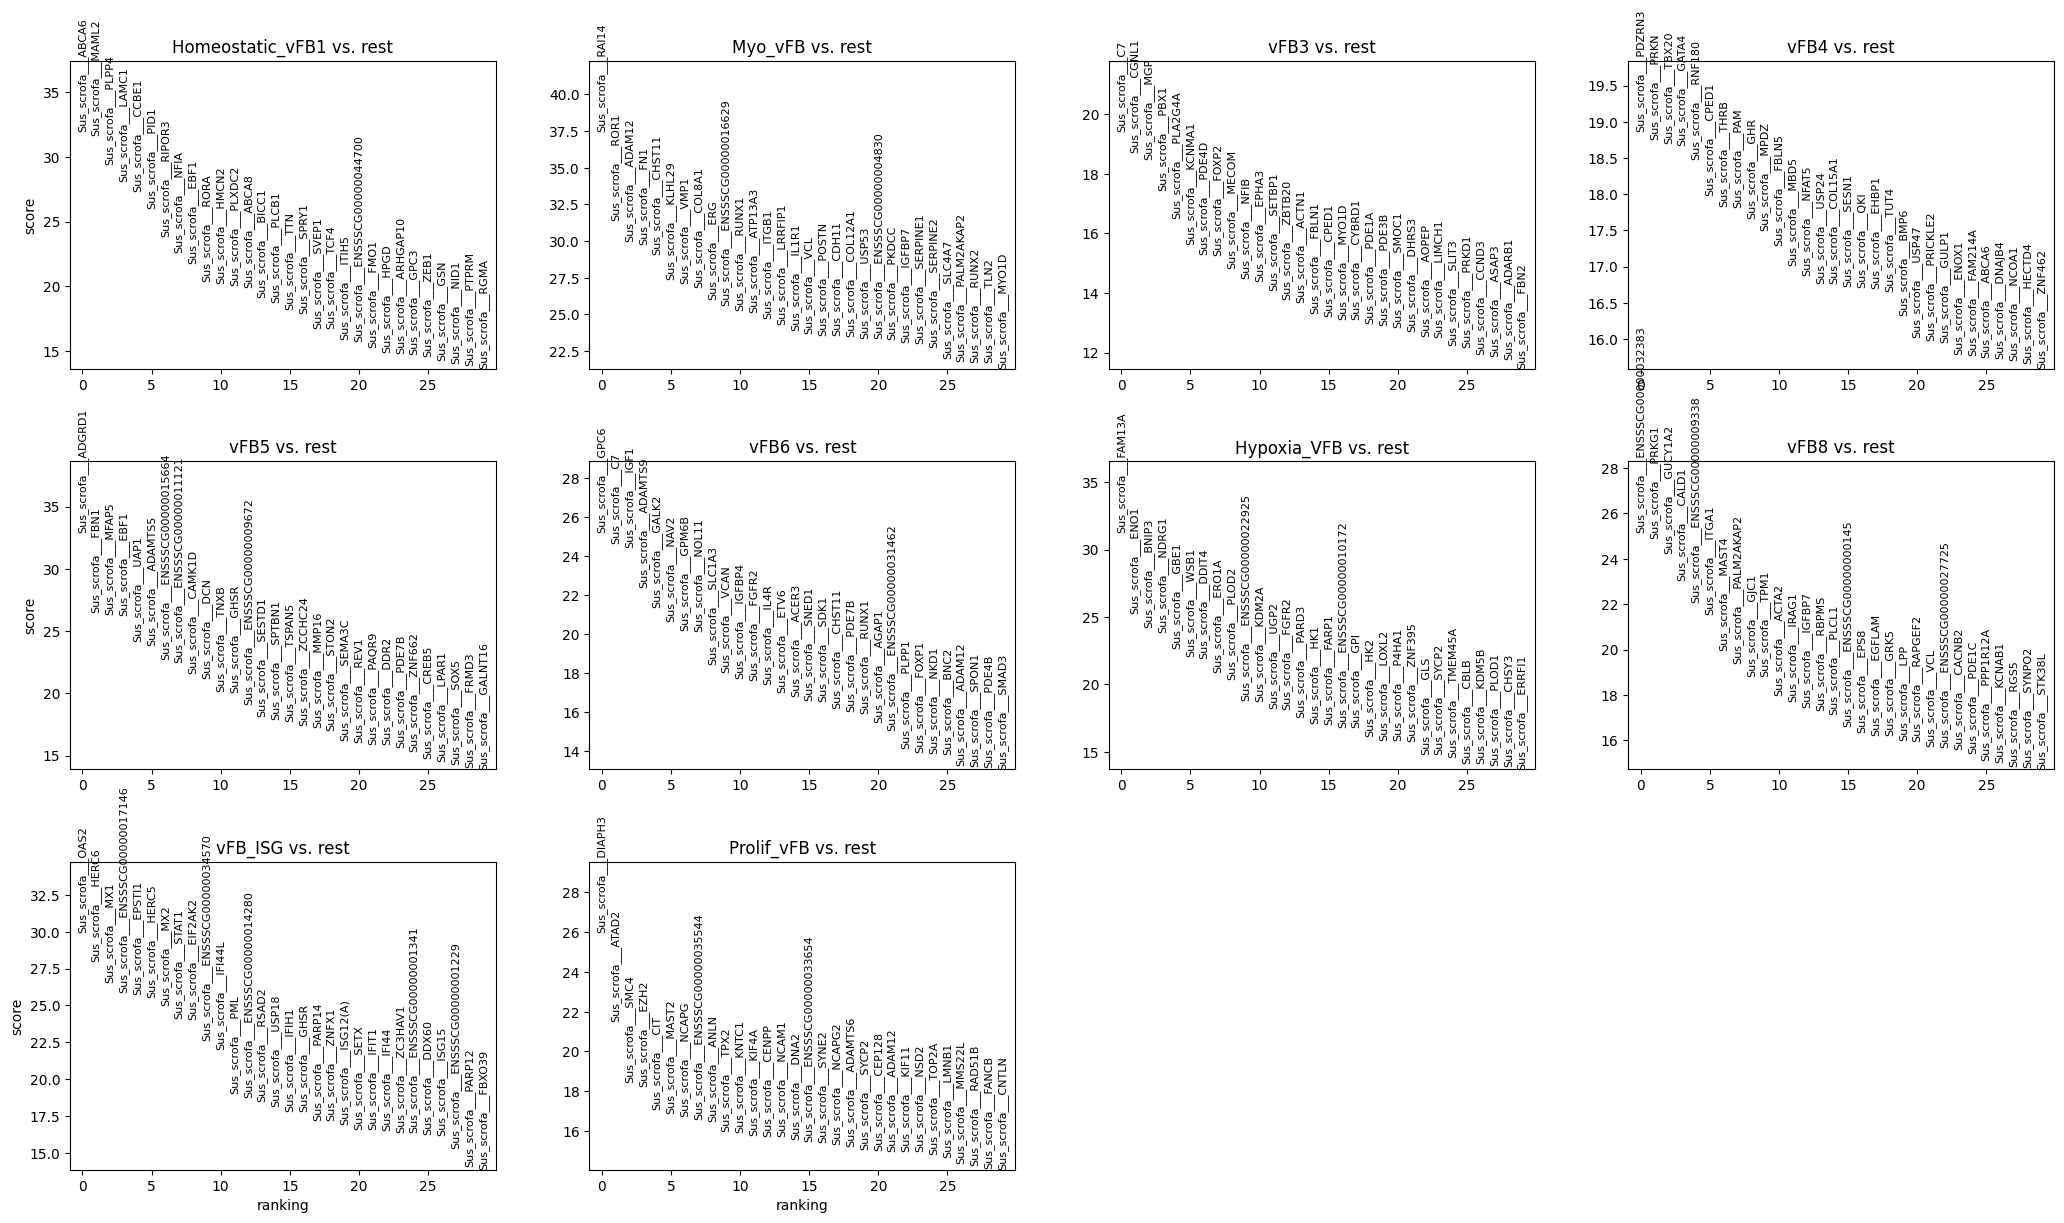

In [16]:
sc.tl.rank_genes_groups(FB_adata, 'cell_states', method='wilcoxon', key_added='wilcoxon', use_raw=True)
# Visualize the top marker genes for each cluster
sc.pl.rank_genes_groups(FB_adata, key='wilcoxon', n_genes=30, sharey=False)

In [ ]:
# --- Save the updated AnnData object ---
save_dir_files = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/For_Manuscript/files"
os.makedirs(save_dir_files, exist_ok=True)
out_path_h5ad = os.path.join(save_dir_files, "FB_adata_cellstates_renamed.h5ad")
FB_adata.write(out_path_h5ad)
print(f"Saved updated AnnData to: {out_path_h5ad}")

<Axes: title={'center': 'cell_states'}, xlabel='UMAP1', ylabel='UMAP2'>

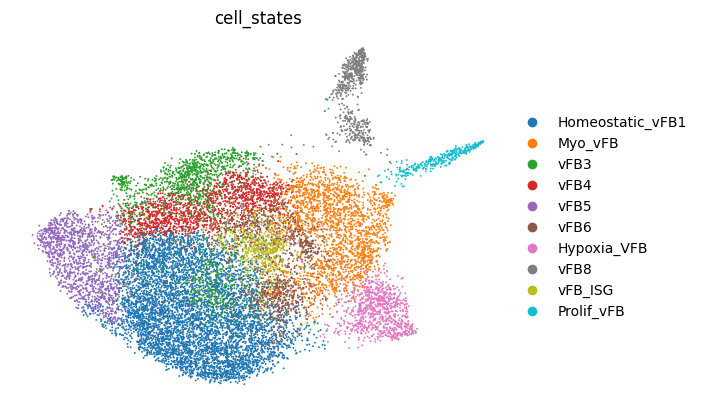

In [17]:
# --- Plot UMAP with the new names ---
sc.pl.umap(
    FB_adata,
    color="cell_states",
    frameon=False,
    show=False
)
# save_dir_results = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/For_Manuscript/Results"
# os.makedirs(save_dir_results, exist_ok=True)
# out_path_umap_pdf = os.path.join(save_dir_results, "Fibroblasts_UMAP.pdf")
# plt.savefig(out_path_umap_pdf, dpi=300, bbox_inches="tight", format="pdf")
# plt.close()
# print(f"UMAP saved as PDF (300 dpi): {out_path_umap_pdf}")


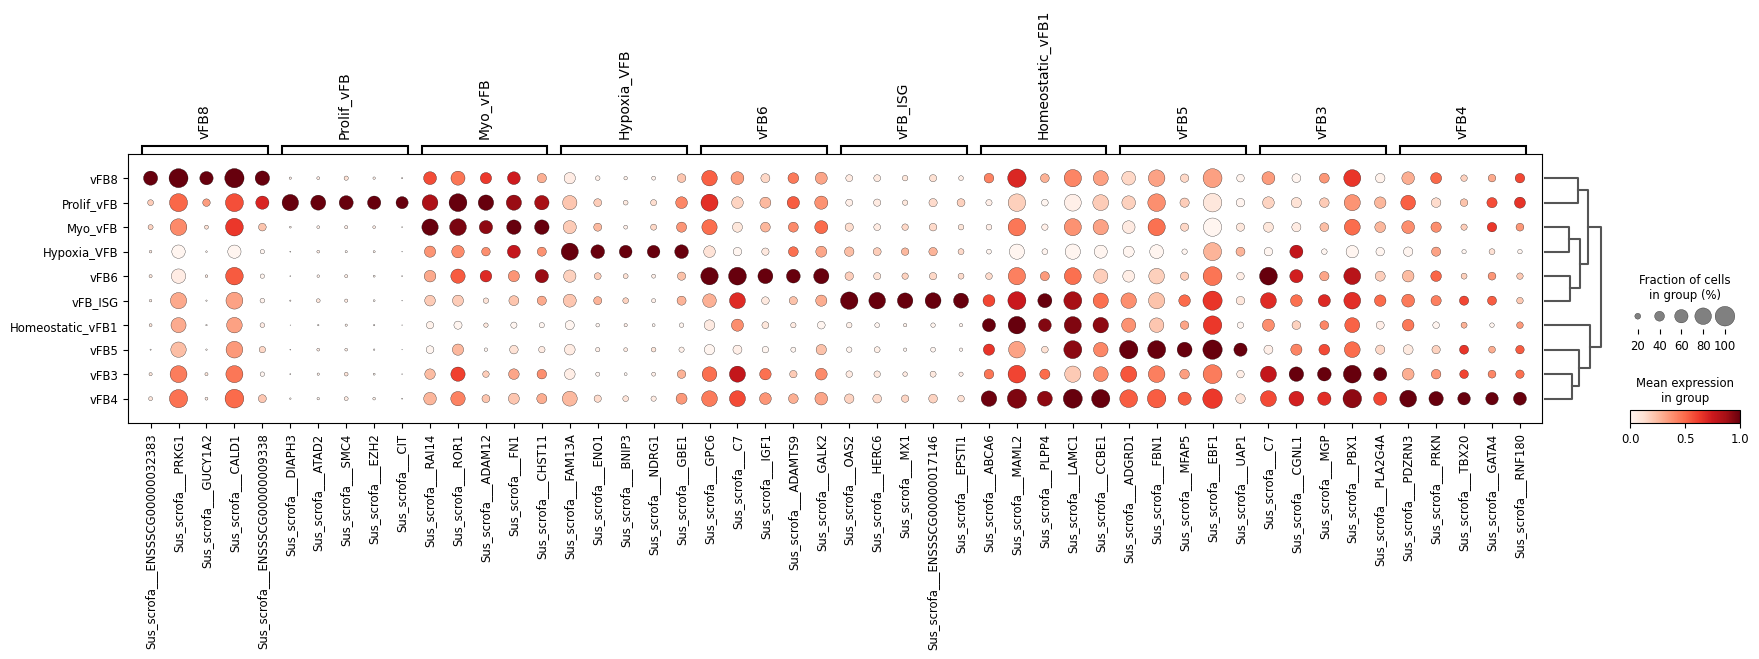

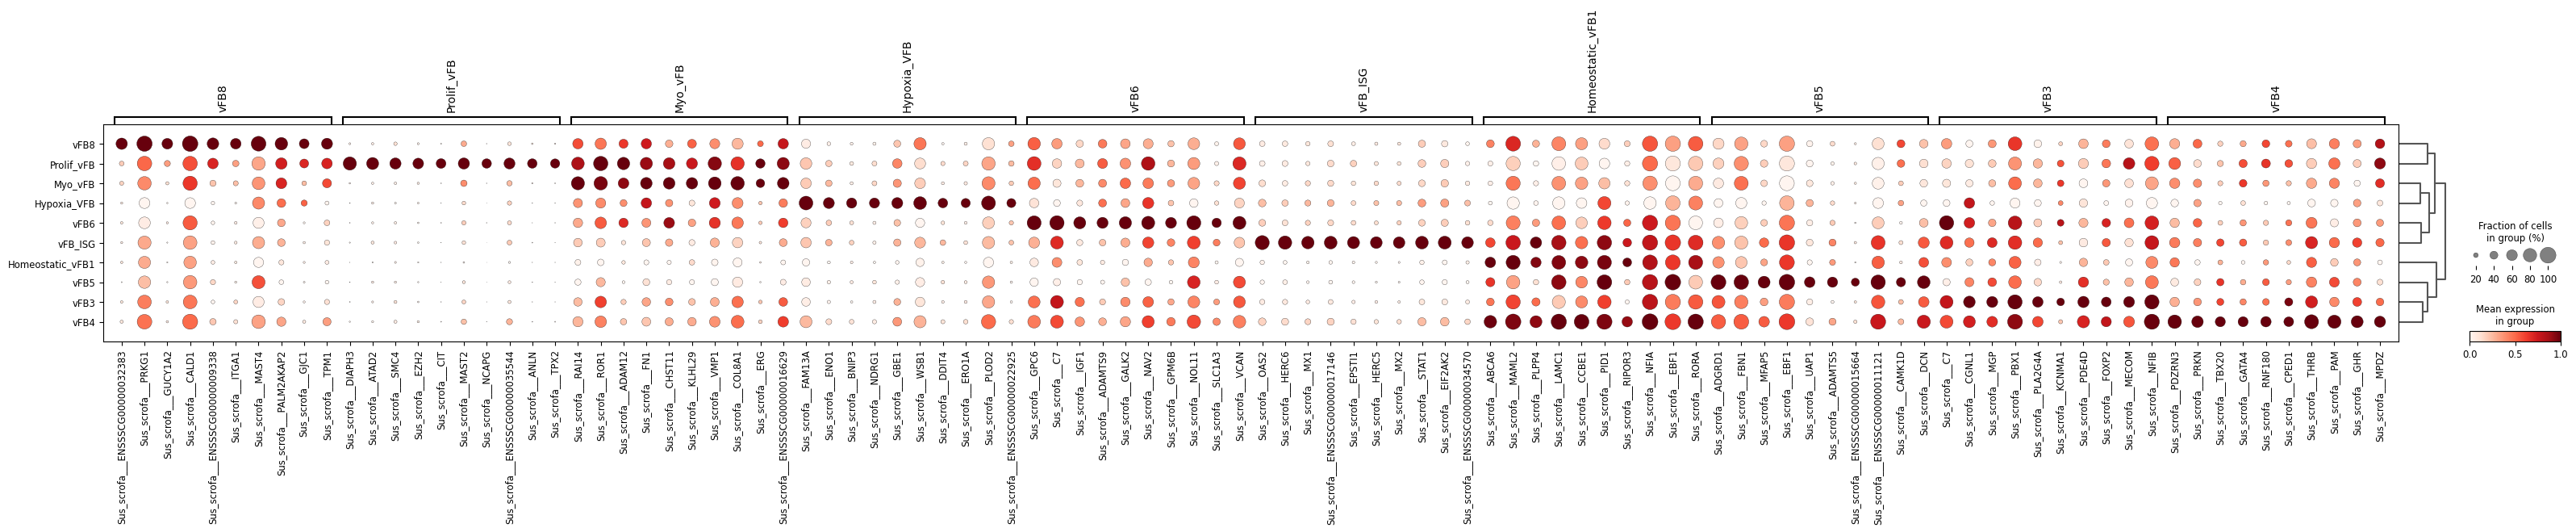

In [19]:
# --- Plot dotplot with the new, corrected results ---
# Now, this plot will work without an error.
sc.pl.rank_genes_groups_dotplot(FB_adata, key="wilcoxon", n_genes=5, standard_scale="var")
plt.close()

sc.pl.rank_genes_groups_dotplot(FB_adata, key="wilcoxon", n_genes=10, standard_scale="var")
plt.close()

In [ ]:
dea_fb_annotated = sc.read ("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/For_Manuscript/files/DEA_FB_annotated_adata.h5ad")

In [ ]:
# import pandas as pd

# # Your mapping table (you can also load it from CSV if you saved it separately)
# mapping_df = pd.DataFrame({
#     "Sample_ID": [
#         "PAV66","PAV82","PAV75","PAV78","PAV72","PAV85","PAV65","PAV76","PAV71","PAV86",
#         "PAV68","PAV84","PAV73","PAV79","PAV74","PAV83","PAV67","PAV69","PAV80",
#         "B","E","F","G"
#     ],
#     "Condition_subsets": [
#         "Standard protocol","Standard protocol","Standard protocol","Rejection","Extended protocol",
#         "Extended protocol","Standard protocol","Rejection","Extended protocol","Rejection",
#         "PCMV/PRV","Prematurely terminated","PCMV/PRV","Rejection","PCMV/PRV","Prematurely terminated",
#         "Standard protocol","Standard protocol","Standard protocol",
#         "Control","Control","Control","Control"
#     ]
# })

# # Merge into obs using Sample_ID
# FB_adata.obs = FB_adata.obs.merge(
#     mapping_df,
#     on="Sample_ID",
#     how="left"
# )

# # Quick check
# print(FB_adata.obs[['Sample_ID','Condition_subsets']].head())
